In [1]:
# importing libraries
import os, time, random, sys
os.environ['PYTHONHASHSEED']=str(1)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('whitegrid')
plt.style.use('seaborn-deep')
plt.style.use('fivethirtyeight')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.serif'] = 'Ubuntu'
plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['figure.figsize'] = (12, 8)

pd.options.mode.chained_assignment = None
pd.options.display.float_format = '{:.2f}'.format
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 400)
import warnings
warnings.filterwarnings('ignore')
import sklearn.metrics as skm
import sklearn.model_selection as skms
import sklearn.preprocessing as skp
import sklearn.utils as sku
from skimage.io import imread
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from tensorflow import keras as k

<ipython-input-1-45359c9d49d6>:10: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-deep')


In [2]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

if tf.config.list_physical_devices('GPU'):
    print("TensorFlow is using the GPU")
else:
    print("TensorFlow is using the CPU")

TensorFlow version: 2.17.1
TensorFlow is using the GPU


In [3]:
seed = 12
def runSeed():
    global seed
    # Set Python's hash seed for reproducibility
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # Set TensorFlow's random seed
    tf.random.set_seed(seed)
    
    # Set NumPy's random seed
    np.random.seed(seed)
    
    # Set Python's built-in random seed
    random.seed(seed)

# Call the function to set seeds
runSeed()

In [4]:
def showImage(img):
    plt.figure(figsize=(2,2))
    plt.imshow(img)
    plt.show()

In [5]:
basePath = '/kaggle/input/deepweeds/'
imgPath = basePath + 'images/'
labelsBase = basePath + 'labels/'
labelsPath = labelsBase + 'labels.csv'
labels_df = pd.read_csv(labelsPath)

## 1. Data Preparation

In [6]:
# constants
batch_size = 32
img_dim = 224 #changeForAnotherModel
epoch=50
def getImgTensor(img_d):
    return (img_d, img_d, 3)
getImgTensor(img_dim)

(224, 224, 3)

In [7]:
# Step 1: Shuffle the DataFrame
shuffled_df = labels_df.sample(frac=1, random_state=seed)

# Step 2: Split into train, val, and test
train_size = 0.75
val_size = 0.15
test_size = 0.1

# Calculate split indices
train_end = int(train_size * len(shuffled_df))
val_end = train_end + int(val_size * len(shuffled_df))

# Split the DataFrame
df_train = shuffled_df[:train_end]
df_val = shuffled_df[train_end:val_end]
df_test = shuffled_df[val_end:]

# Step 3: Reset the index for each split
df_train.reset_index(drop=True, inplace=True)
df_val.reset_index(drop=True, inplace=True)
df_test.reset_index(drop=True, inplace=True)

# Step 4: Convert 'Label' column to string (if needed)
df_train['Label'] = df_train['Label'].astype('str')
df_val['Label'] = df_val['Label'].astype('str')
df_test['Label'] = df_test['Label'].astype('str')

# Print the sizes of the splits to verify
print(f"Training set size: {len(df_train)}")
print(f"Validation set size: {len(df_val)}")
print(f"Test set size: {len(df_test)}")

Training set size: 13131
Validation set size: 2626
Test set size: 1752


Label counts:
Label
8    9106
0    1125
6    1074
1    1064
4    1062
2    1031
3    1022
7    1016
5    1009
Name: count, dtype: int64


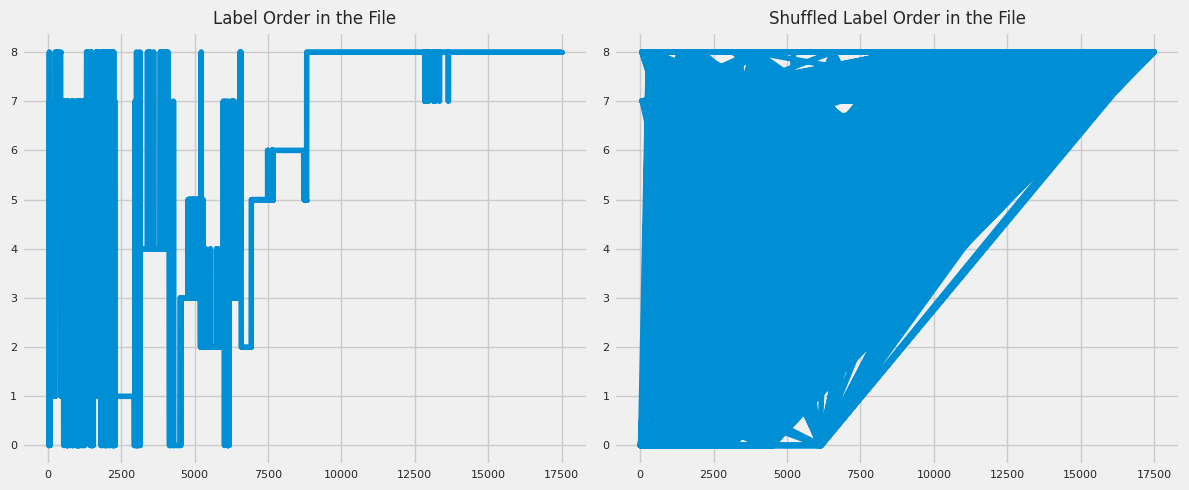

In [8]:
# Check the distribution of labels
label_counts = labels_df['Label'].value_counts()
print("Label counts:")
print(label_counts)

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original label order
axes[0].plot(labels_df['Label'], marker='o', linestyle='-', markersize=2)
axes[0].set_title('Label Order in the File')
axes[0].grid(True)

# Shuffled label order
axes[1].plot(shuffled_df['Label'], marker='o', linestyle='-', markersize=2)
axes[1].set_title('Shuffled Label Order in the File')
axes[1].grid(True)

# Adjust layout and show the plots
plt.tight_layout()
plt.show()

In [9]:
df_train.head()

,Filename,Label,Species
0,20171102-122425-1.jpg,2,Parkinsonia
1,20171109-092312-1.jpg,5,Rubber vine
2,20170728-153128-1.jpg,4,Prickly acacia
3,20171109-093358-1.jpg,5,Rubber vine
4,20170630-152316-0.jpg,0,Chinee apple


In [10]:
# Image Data Generators
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input,#changeForAnotherModel
    # rotation_range=20,
    # width_shift_range=0.2,
    # height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    # vertical_flip=True,
    # brightness_range=[0.8, 1.2],
    # fill_mode='nearest'
)

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input#changeForAnotherModel
)

test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input#changeForAnotherModel
)

In [11]:
# Train Generator
train_generator = train_datagen.flow_from_dataframe(
    directory=imgPath,
    dataframe=df_train,
    x_col='Filename',
    y_col='Label',
    batch_size=batch_size,
    color_mode="rgb",
    seed=seed,
    shuffle=True,
    class_mode="categorical",
    target_size=(img_dim, img_dim)
)

Found 13131 validated image filenames belonging to 9 classes.


In [12]:
# Validation Generator
val_generator = val_datagen.flow_from_dataframe(
    directory=imgPath,
    dataframe=df_val,
    x_col='Filename',
    y_col='Label',
    batch_size=batch_size,
    color_mode="rgb",
    seed=seed,
    shuffle=False,
    class_mode="categorical",
    target_size=getImgTensor(img_dim)[:2]
)

# Test Generator
test_generator = test_datagen.flow_from_dataframe(
    directory=imgPath,
    dataframe=df_test,
    x_col='Filename',
    y_col='Label',
    batch_size=batch_size,
    color_mode="rgb",
    seed=seed,
    shuffle=False,
    class_mode="categorical",
    target_size=getImgTensor(img_dim)[:2]
)

Found 2626 validated image filenames belonging to 9 classes.
Found 1752 validated image filenames belonging to 9 classes.


In [13]:
# Compute class weights with balanced data
class_weights = sku.class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
train_class_weights = {i: x for i, x in enumerate(class_weights)}
print("class weights:", train_class_weights)

class weights: {0: 1.7990135635018496, 1: 1.8753213367609254, 2: 1.922266139657444, 3: 1.8777348777348777, 4: 1.777101096224117, 5: 1.9557640750670242, 6: 1.7727825030376672, 7: 1.9583892617449665, 8: 0.21234172609518265}


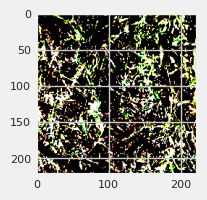

[[0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]]
Batch Size 32


In [14]:
# Get a batch of data
images, labels = next(train_generator)
#Show image
showImage(images[0])
# Print the labels
print(labels)
print("Batch Size",len(labels))

In [15]:
total_samples = train_generator.n
print(f"Total number of samples: {total_samples}")
class_counts = df_train['Label'].value_counts()
print("Number of samples per class:")
print(class_counts)

Total number of samples: 13131
Number of samples per class:
Label
8    6871
6     823
4     821
0     811
1     778
3     777
2     759
5     746
7     745
Name: count, dtype: int64


Batch size: 32


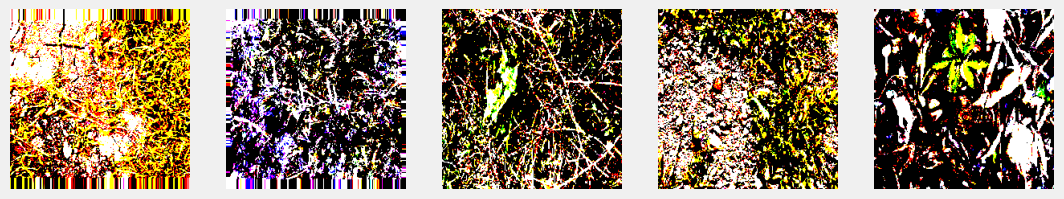

In [16]:
import matplotlib.pyplot as plt

# Get one batch
batch_images, batch_labels = next(train_generator)
print(f"Batch size: {batch_images.shape[0]}")

# Plot a few images from the batch
for i in range(min(5, batch_size)):
    plt.subplot(1, 5, i+1)
    plt.imshow(batch_images[i])
    plt.axis('off')
plt.show()

In [24]:
import tensorflow as tf
from tensorflow import keras as k
from tensorflow.keras import layers

def cbam_block(x, ratio=8, spatial_kernel=7, name="cbam"):
    c = x.shape[-1]

    gap = layers.GlobalAveragePooling2D(name=f"{name}_gap")(x)
    gmp = layers.GlobalMaxPooling2D(name=f"{name}_gmp")(x)

    shared_mlp = k.Sequential([
        layers.Dense(c // ratio, activation="relu", use_bias=True),
        layers.Dense(c, use_bias=True)
    ], name=f"{name}_mlp")

    mlp_gap = shared_mlp(gap)
    mlp_gmp = shared_mlp(gmp)
    ch = layers.Activation("sigmoid", name=f"{name}_ch_sigmoid")(mlp_gap + mlp_gmp)
    ch = layers.Reshape((1, 1, c), name=f"{name}_ch_reshape")(ch)
    x = layers.Multiply(name=f"{name}_ch_scale")([x, ch])

    # Spatial attention (avg+max across channels -> conv)
    avg_pool = layers.Lambda(lambda t: tf.reduce_mean(t, axis=-1, keepdims=True),
                             name=f"{name}_sp_avg")(x)
    max_pool = layers.Lambda(lambda t: tf.reduce_max(t, axis=-1, keepdims=True),
                             name=f"{name}_sp_max")(x)
    concat = layers.Concatenate(axis=-1, name=f"{name}_sp_concat")([avg_pool, max_pool])
    sp = layers.Conv2D(1, kernel_size=spatial_kernel, padding="same",
                       activation="sigmoid", name=f"{name}_sp_conv")(concat)
    x = layers.Multiply(name=f"{name}_sp_scale")([x, sp])
    return x

input_shape = getImgTensor(img_dim) 
num_classes = len(train_generator.class_indices)

base_model = k.applications.ResNet50(
    input_shape=input_shape,
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  

inputs = k.Input(shape=input_shape)
feat = base_model(inputs)             
feat = cbam_block(feat, ratio=8, spatial_kernel=7, name="cbam") 
x = layers.GlobalAveragePooling2D(name="gap")(feat)

x = layers.Dense(1024, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(num_classes, activation='softmax')(x)
model = k.Model(inputs, outputs, name="resnet50_cbam")

model.compile(
    optimizer=k.optimizers.Adam(learning_rate=5e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

for layer in base_model.layers[-20:]:
    layer.trainable = True

model.compile(
    optimizer=k.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history_cbam = model.fit(
    train_generator,
    epochs=epoch,
    class_weight=train_class_weights,
    validation_data=val_generator
)

model.save("ResNet50CBAM.h5")


Model: "resnet50_cbam"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ resnet50 (Functional)     │ (None, 7, 7, 2048)     │     23,587,712 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ cbam_gap                  │ (None, 2048)           │              0 │ resnet50[0][0]         │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ cbam_gmp                  │ (None, 2048)           │              0 │ resnet50[0][0]         │
│ (GlobalMaxPooling2D)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ cbam_mlp (Sequential)     │ (None, 2048)           │      1,050,880 │ cbam_gap[0][0],        │
│                           │                        │                │ cbam_gmp[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 2048)           │              0 │ cbam_mlp[0][0],        │
│                           │                        │                │ cbam_mlp[1][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ cbam_ch_sigmoid           │ (None, 2048)           │              0 │ add[0][0]              │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ cbam_ch_reshape (Reshape) │ (None, 1, 1, 2048)     │              0 │ cbam_ch_sigmoid[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ cbam_ch_scale (Multiply)  │ (None, 7, 7, 2048)     │              0 │ resnet50[0][0],        │
│                           │                        │                │ cbam_ch_reshape[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ cbam_sp_avg (Lambda)      │ (None, 7, 7, 1)        │              0 │ cbam_ch_scale[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ cbam_sp_max (Lambda)      │ (None, 7, 7, 1)        │              0 │ cbam_ch_scale[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ cbam_sp_concat            │ (None, 7, 7, 2)        │              0 │ cbam_sp_avg[0][0],     │
│ (Concatenate)             │                        │                │ cbam_sp_max[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ cbam_sp_conv (Conv2D)     │ (None, 7, 7, 1)        │             99 │ cbam_sp_concat[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ cbam_sp_scale (Multiply)  │ (None, 7, 7, 2048)     │              0 │ cbam_ch_scale[0][0],   │
│                           │                        │                │ cbam_sp_conv[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gap                       │ (None, 2048)           │              0 │ cbam_sp_scale[0][0]    │
│ (GlobalAveragePooling

 Total params: 27,270,380 (104.03 MB)

 Trainable params: 12,611,948 (48.11 MB)

 Non-trainable params: 14,658,432 (55.92 MB)

Epoch 1/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 187s 396ms/step - accuracy: 0.3599 - loss: 1.6460 - val_accuracy: 0.6024 - val_loss: 1.3360
Epoch 2/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 159s 381ms/step - accuracy: 0.6534 - loss: 0.7591 - val_accuracy: 0.7281 - val_loss: 0.8774
Epoch 3/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 161s 384ms/step - accuracy: 0.7354 - loss: 0.5534 - val_accuracy: 0.7761 - val_loss: 0.6476
Epoch 4/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 160s 383ms/step - accuracy: 0.7793 - loss: 0.4681 - val_accuracy: 0.7464 - val_loss: 0.7820
Epoch 5/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 162s 386ms/step - accuracy: 0.8153 - loss: 0.3759 - val_accuracy: 0.7624 - val_loss: 0.7544
Epoch 6/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 154s 368ms/step - accuracy: 0.8270 - loss: 0.3249 - val_accuracy: 0.7887 - val_loss: 0.6938
Epoch 7/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 159s 380ms/step - accuracy: 0.8531 - loss: 0.2917 - val_accuracy: 0.7669 - val_loss: 0.7650
Epoch 8/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 168s 403ms/step - accuracy: 0.8563 -

In [25]:
# Evaluate the model on test data
test_loss, test_acc = model.evaluate(test_generator)
print(f'\nTest accuracy: {test_acc:.4f}')
print(f'Test loss: {test_loss:.4f}')

55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 149ms/step - accuracy: 0.8583 - loss: 0.5450

Test accuracy: 0.8659
Test loss: 0.5103


In [26]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get true labels and predictions
test_generator.reset()  # Important to reset generator before predictions
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# Get class labels
class_labels = list(test_generator.class_indices.keys())

# Classification report
print('\nClassification Report:')
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

55/55 ━━━━━━━━━━━━━━━━━━━━ 12s 148ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.81      0.79       122
           1       0.75      0.93      0.83       110
           2       0.95      0.80      0.87        96
           3       0.75      0.96      0.84        90
           4       0.74      0.94      0.83       108
           5       0.78      0.96      0.86       105
           6       0.72      0.96      0.82        97
           7       0.78      0.87      0.82        98
           8       0.98      0.83      0.90       926

    accuracy                           0.87      1752
   macro avg       0.80      0.90      0.84      1752
weighted avg       0.89      0.87      0.87      1752



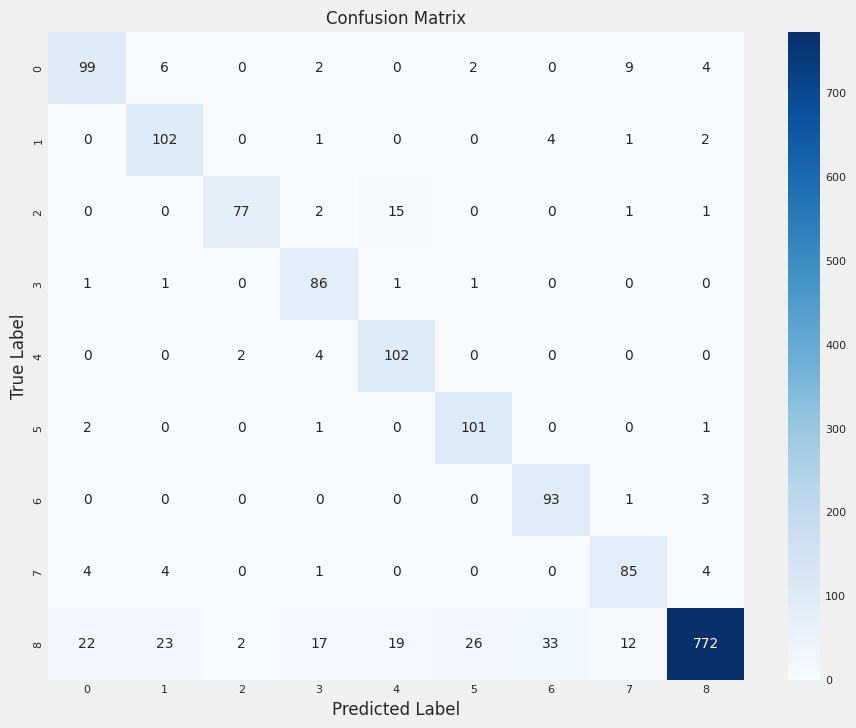

In [27]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, 
            yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

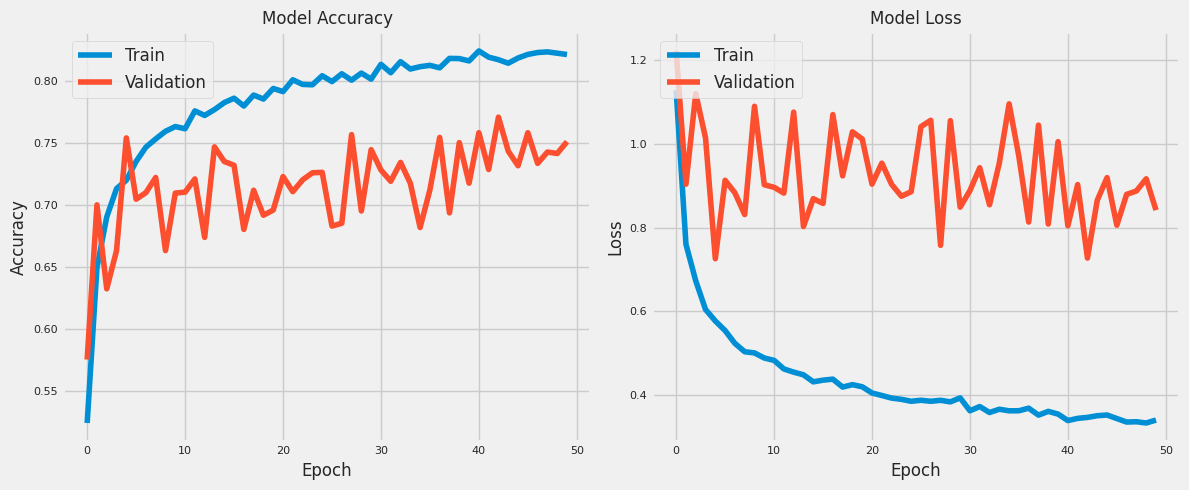

In [28]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

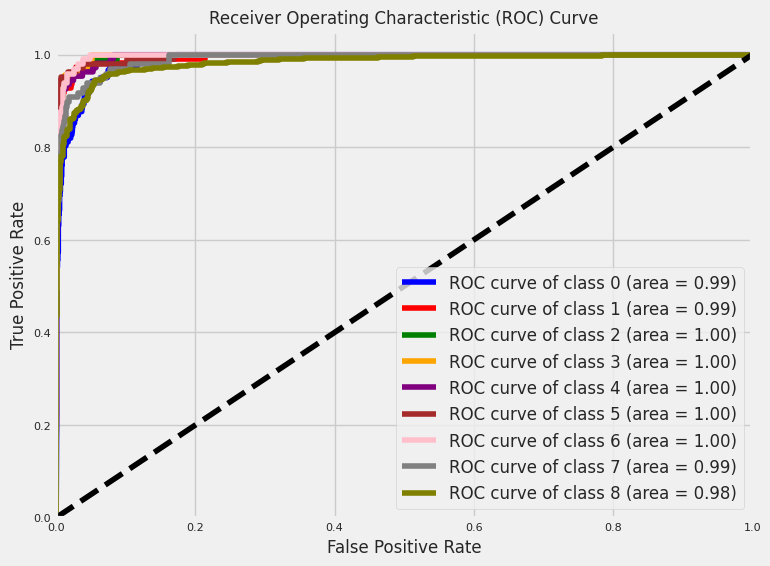

In [29]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize the output for multiclass ROC
y_test_bin = label_binarize(y_true, classes=np.arange(len(class_labels)))
n_classes = y_test_bin.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive']
for i, color in zip(range(n_classes), colors[:n_classes]):
    plt.plot(fpr[i], tpr[i], color=color,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(class_labels[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

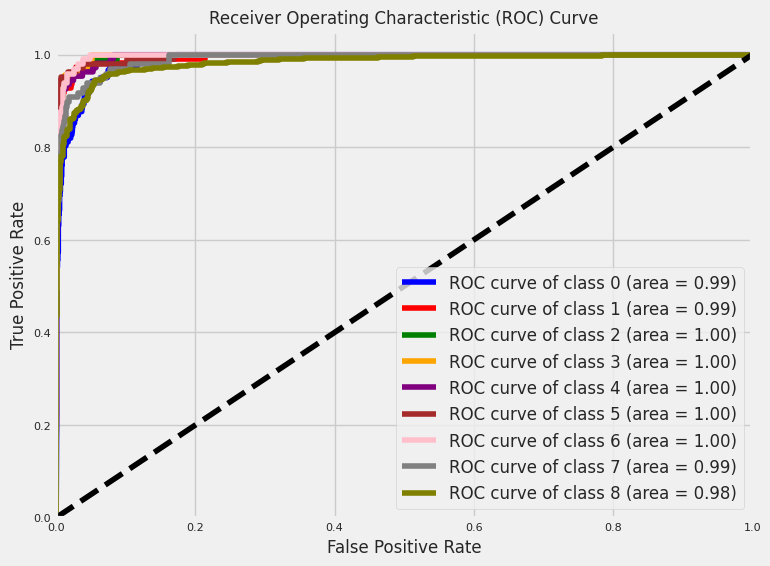

In [30]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize the output for multiclass ROC
y_test_bin = label_binarize(y_true, classes=np.arange(len(class_labels)))
n_classes = y_test_bin.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive']
for i, color in zip(range(n_classes), colors[:n_classes]):
    plt.plot(fpr[i], tpr[i], color=color,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(class_labels[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

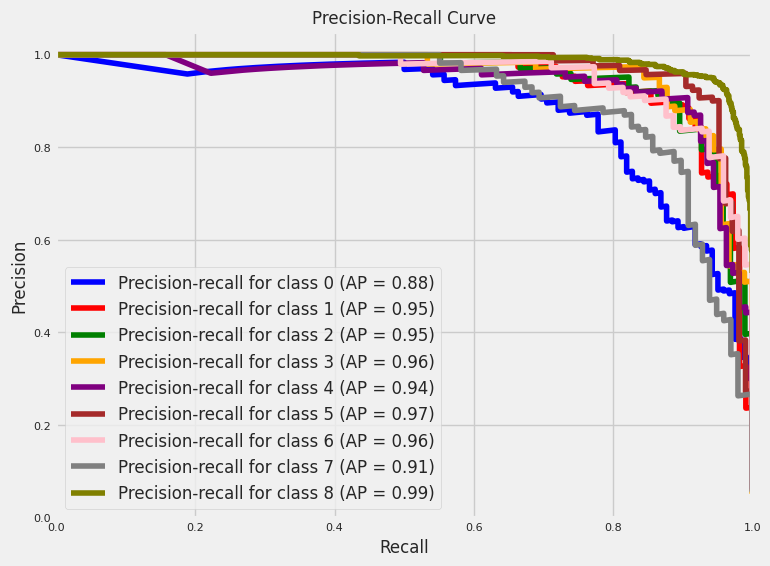

In [31]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# For each class
precision = dict()
recall = dict()
average_precision = dict()
for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_pred[:, i])
    average_precision[i] = average_precision_score(y_test_bin[:, i], y_pred[:, i])

# Plot Precision-Recall curve for each class
plt.figure(figsize=(8, 6))
for i, color in zip(range(n_classes), colors[:n_classes]):
    plt.plot(recall[i], precision[i], color=color,
             label='Precision-recall for class {0} (AP = {1:0.2f})'
             ''.format(class_labels[i], average_precision[i]))

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

In [37]:
import tensorflow as tf
from tensorflow import keras as k
from tensorflow.keras import layers

# Positional encoding layer
class AddLearnedPos(layers.Layer):
    def build(self, input_shape):
        # Extract sequence length (T) and feature dimension (D) from input_shape
        T = input_shape[1]  # Sequence length
        D = input_shape[2]  # Feature dimension
        # Initialize the positional embeddings with shape (T, D)
        self.pos = self.add_weight(
            name="pos_emb",
            shape=(int(T), int(D)),
            initializer="zeros",
            trainable=True
        )

    def call(self, x):
        # Return the input tensor x with the positional encoding added
        return x + self.pos  # Broadcasting will handle different batch sizes

# Transformer encoder layer
def transformer_encoder(x, num_heads=4, key_dim=64, mlp_dim=512, dropout=0.0, name="tx"):
    h = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_ln1")(x)
    h = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim,
                                  dropout=dropout, name=f"{name}_mha")(h, h)
    x = layers.Add(name=f"{name}_res1")([x, h])

    h = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_ln2")(x)
    h = layers.Dense(mlp_dim, activation="gelu", name=f"{name}_mlp1")(h)
    h = layers.Dropout(dropout, name=f"{name}_drop")(h)
    h = layers.Dense(x.shape[-1], name=f"{name}_mlp2")(h)
    x = layers.Add(name=f"{name}_res2")([x, h])
    return x

# ViT head from feature map
def vit_head_from_feature_map(feat_map,
                              d_model=256,
                              depth=2,
                              num_heads=4,
                              key_dim=64,
                              mlp_dim=512,
                              dropout=0.0,
                              use_cls_token=False,
                              name="vit"):

    _, H, W, C = feat_map.shape
    x = layers.Reshape((H * W, C), name=f"{name}_tokens")(feat_map)      
    x = layers.Dense(d_model, name=f"{name}_proj")(x)                    
    x = AddLearnedPos(name=f"{name}_pos")(x)

    if use_cls_token:
        # Optional: learnable [CLS] token
        cls = tf.Variable(tf.zeros((1, 1, d_model)), trainable=True, name=f"{name}_cls")
        b = tf.shape(x)[0]
        cls_tiled = tf.tile(cls, [b, 1, 1])
        x = layers.Concatenate(axis=1, name=f"{name}_addcls")([cls_tiled, x])

    for i in range(depth):
        x = transformer_encoder(x, num_heads=num_heads, key_dim=key_dim,
                                mlp_dim=mlp_dim, dropout=dropout, name=f"{name}_blk{i+1}")

    if use_cls_token:
        # Take the [CLS] token
        x = layers.Lambda(lambda t: t[:, 0], name=f"{name}_cls_take")(x)
    else:
        # Mean pool tokens
        x = layers.GlobalAveragePooling1D(name=f"{name}_tokpool")(x)
    return x

# Input shape and number of classes
input_shape = (224, 224, 3)  # Example input shape for images
num_classes = 10  # Set this based on your dataset

# Load base model (ResNet50)
base_model = k.applications.ResNet50(
    input_shape=input_shape,
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # Freeze first

# Build the model
inputs = k.Input(shape=input_shape)
feat = base_model(inputs)  # (B, H/32, W/32, C)

# ViT head
vit_vec = vit_head_from_feature_map(
    feat,
    d_model=256,
    depth=2,            
    num_heads=4,
    key_dim=64,
    mlp_dim=512,
    dropout=0.0,
    use_cls_token=False,
    name="vit"
)

x = layers.Dense(1024, activation='relu', name="fc1")(vit_vec)
x = layers.BatchNormalization(name="bn1")(x)
x = layers.Dropout(0.3, name="do1")(x)
x = layers.Dense(512, activation='relu', name="fc2")(x)
x = layers.Dropout(0.3, name="do2")(x)

# Final output layer
outputs = layers.Dense(num_classes, activation='softmax', name="logits")(x)

# Create the model
model = k.Model(inputs, outputs, name="resnet50_vit")

# Compile the model
model.compile(
    optimizer=k.optimizers.Adam(learning_rate=5e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Unfreeze some layers in the base model
for layer in base_model.layers[-20:]:
    layer.trainable = True

# Re-compile the model after unfreezing layers
model.compile(
    optimizer=k.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

# Train the model (replace with actual data generators)
# history_vit = model.fit(
#     train_generator,
#     epochs=10,
#     class_weight=train_class_weights,
#     validation_data=val_generator
# )

Model: "resnet50_vit"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16            │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ resnet50 (Functional)     │ (None, 7, 7, 2048)     │     23,587,712 │ input_layer_16[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ vit_tokens (Reshape)      │ (None, 49, 2048)       │              0 │ resnet50[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ vit_proj (Dense)          │ (None, 49, 256)        │        524,544 │ vit_tokens[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ vit_pos (AddLearnedPos)   │ (None, 49, 256)        │         12,544 │ vit_proj[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ vit_blk1_ln1              │ (None, 49, 256)        │            512 │ vit_pos[0][0]          │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ vit_blk1_mha              │ (None, 49, 256)        │        263,168 │ vit_blk1_ln1[0][0],    │
│ (MultiHeadAttention)      │                        │                │ vit_blk1_ln1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ vit_blk1_res1 (Add)       │ (None, 49, 256)        │              0 │ vit_pos[0][0],         │
│                           │                        │                │ vit_blk1_mha[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ vit_blk1_ln2              │ (None, 49, 256)        │            512 │ vit_blk1_res1[0][0]    │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ vit_blk1_mlp1 (Dense)     │ (None, 49, 512)        │        131,584 │ vit_blk1_ln2[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ vit_blk1_drop (Dropout)   │ (None, 49, 512)        │              0 │ vit_blk1_mlp1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ vit_blk1_mlp2 (Dense)     │ (None, 49, 256)        │        131,328 │ vit_blk1_drop[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ vit_blk1_res2 (Add)       │ (None, 49, 256)        │              0 │ vit_blk1_res1[0][0],   │
│                           │                        │                │ vit_blk1_mlp2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ vit_blk2_ln1              │ (None, 49, 256)        │            512 │ vit_blk1_res2[0][0]    │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ vit_blk2_mha              │ (None, 49, 256)        │        263,168 │ vit_blk2_ln1[0][0],    │
│ (MultiHeadAttention)      │                        │                │ vit_blk2_ln1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ vit_blk2_res1 (Add)  

 Total params: 25,976,202 (99.09 MB)

 Trainable params: 11,317,770 (43.17 MB)

 Non-trainable params: 14,658,432 (55.92 MB)

In [39]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense

# Modify the model
new_output = Dense(9, activation='softmax')(model.layers[-2].output)
new_model = Model(inputs=model.input, outputs=new_output)

# Compile the model
new_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Evaluate
test_loss, test_acc = new_model.evaluate(test_generator)
print(f'\nTest accuracy: {test_acc:.4f}')
print(f'Test loss: {test_loss:.4f}')

55/55 ━━━━━━━━━━━━━━━━━━━━ 15s 155ms/step - accuracy: 0.2277 - loss: 2.1002

Test accuracy: 0.2158
Test loss: 2.1120


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get true labels and predictions
test_generator.reset()  # Important to reset generator before predictions
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# Get class labels
class_labels = list(test_generator.class_indices.keys())

# Classification report
print('\nClassification Report:')
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, 
            yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize the output for multiclass ROC
y_test_bin = label_binarize(y_true, classes=np.arange(len(class_labels)))
n_classes = y_test_bin.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive']
for i, color in zip(range(n_classes), colors[:n_classes]):
    plt.plot(fpr[i], tpr[i], color=color,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(class_labels[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# For each class
precision = dict()
recall = dict()
average_precision = dict()
for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_pred[:, i])
    average_precision[i] = average_precision_score(y_test_bin[:, i], y_pred[:, i])

# Plot Precision-Recall curve for each class
plt.figure(figsize=(8, 6))
for i, color in zip(range(n_classes), colors[:n_classes]):
    plt.plot(recall[i], precision[i], color=color,
             label='Precision-recall for class {0} (AP = {1:0.2f})'
             ''.format(class_labels[i], average_precision[i]))

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()